In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf

# Important imports for preprocessing, modeling, and evaluation.
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

# Logistic regression in Python

- Main resource: An Introduction to Statistical Learning with Application in Python

In this notebook, I will investigate properties and application of Logistic Regression using Python libraries and comparing results with DIY functions.

Consider again the `Default` data set, where the response default falls into one of two categories, `Yes` or `No`

In [8]:
data = pd.read_csv('./Data/Default.csv')
data.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138947
3,No,No,529.250605,35704.493935
4,No,No,785.655883,38463.495879


In [14]:
lst = ['Yes']
data['default_int'] = [int(x in lst) for x in data['default'].values]

In [5]:
data.default.value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

Rather than modeling this response $Y$ directly, logistic regression ***models the probability*** that $Y$ belongs to a particular category. For the `Default` data, logistic regression models the probability of default.

For example, the probability of default given balance can be written as

$$
Pr(\text{default} = \text{Yes} | \text{balance})
$$

This probability ranging from 0 to 1. Then for any given value of `balance`, a prediction can be made for `default`. 

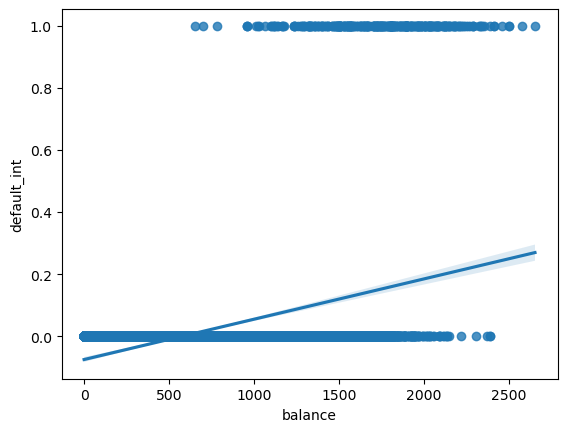

In [19]:
sns.regplot(
    data = data,
    x = 'balance',
    y = 'default_int'
);

In [20]:
f = 'default_int ~ balance'
linear_model = smf.ols(formula=f, data=data).fit()

In [21]:
linear_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            default_int   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     1397.
Date:                Wed, 05 Feb 2025   Prob (F-statistic):          2.77e-286
Time:                        13:47:02   Log-Likelihood:                 3644.8
No. Observations:               10000   AIC:                            -7286.
Df Residuals:                    9998   BIC:                            -7271.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0752      0.003    -22.416      0.000      -0.082      -0.069
balance        0.0001   3.47e-06     37.374      0.000       0.000       0.000
==============================================================================
Omnibus:                     8547.967   Durbin-Watson:                   2.023
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           180810.806
Skew:                           4.243   Prob(JB):                         0.00
Kurtosis:                      22.025   Cond. No.                     1.93e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.93e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [27]:
logistic_model = smf.logit(formula=f, data=data).fit()

Optimization terminated successfully.
         Current function value: 0.079823
         Iterations 10


In [24]:
logistic_model.params

Intercept   -10.651331
balance       0.005499
dtype: float64

In [32]:
def logit_px(x, intercept, coeff):
    n = np.exp(intercept+coeff*x)
    d = 1+(np.exp(intercept+coeff*x))
    return(n/d)

In [28]:
logistic_model.predict()

array([1.30567967e-03, 2.11259491e-03, 8.59474052e-03, ...,
       2.46651298e-03, 1.16759613e-01, 7.14474975e-05])

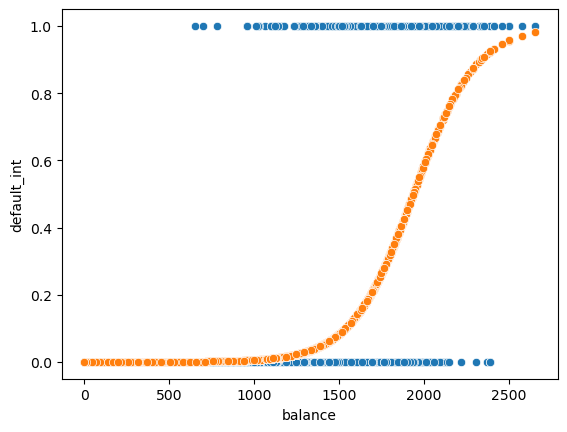

In [31]:
sns.scatterplot(
    data = data,
    x = 'balance',
    y = 'default_int'
)
sns.scatterplot(
    x=data['balance'],
    y = logistic_model.predict()
);

In [51]:
predicted = logit_px(
    x=data['balance'].values,
    intercept=logistic_model.params['Intercept'],
    coeff=logistic_model.params['balance']
)

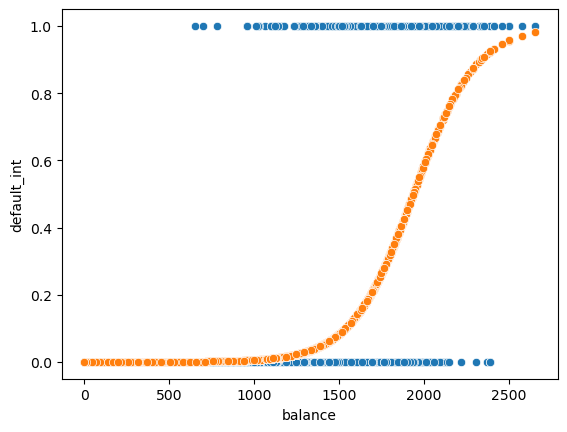

In [52]:
sns.scatterplot(
    data = data,
    x = 'balance',
    y = 'default_int'
)
sns.scatterplot(
    x=data['balance'],
    y = predicted
);

In [57]:
data['default'].value_counts()

default
No     9667
Yes     333
Name: count, dtype: int64

In [58]:
333/(9667+333)

0.0333

In [40]:
outcomes = np.arange(1,37)

In [41]:
p = outcomes/36

In [42]:
p

array([0.02777778, 0.05555556, 0.08333333, 0.11111111, 0.13888889,
       0.16666667, 0.19444444, 0.22222222, 0.25      , 0.27777778,
       0.30555556, 0.33333333, 0.36111111, 0.38888889, 0.41666667,
       0.44444444, 0.47222222, 0.5       , 0.52777778, 0.55555556,
       0.58333333, 0.61111111, 0.63888889, 0.66666667, 0.69444444,
       0.72222222, 0.75      , 0.77777778, 0.80555556, 0.83333333,
       0.86111111, 0.88888889, 0.91666667, 0.94444444, 0.97222222,
       1.        ])

In [43]:
o = outcomes/(36-outcomes)

C:\Users\pacor\AppData\Local\Temp\ipykernel_20092\3530259093.py:1: RuntimeWarning: divide by zero encountered in divide
  o = outcomes/(36-outcomes)


In [44]:
o

array([2.85714286e-02, 5.88235294e-02, 9.09090909e-02, 1.25000000e-01,
       1.61290323e-01, 2.00000000e-01, 2.41379310e-01, 2.85714286e-01,
       3.33333333e-01, 3.84615385e-01, 4.40000000e-01, 5.00000000e-01,
       5.65217391e-01, 6.36363636e-01, 7.14285714e-01, 8.00000000e-01,
       8.94736842e-01, 1.00000000e+00, 1.11764706e+00, 1.25000000e+00,
       1.40000000e+00, 1.57142857e+00, 1.76923077e+00, 2.00000000e+00,
       2.27272727e+00, 2.60000000e+00, 3.00000000e+00, 3.50000000e+00,
       4.14285714e+00, 5.00000000e+00, 6.20000000e+00, 8.00000000e+00,
       1.10000000e+01, 1.70000000e+01, 3.50000000e+01,            inf])

In [45]:
15/11

1.3636363636363635

In [47]:
pd.DataFrame({
    'p':p,
    'o':o
})

,p,o
0,0.027778,0.028571
1,0.055556,0.058824
2,0.083333,0.090909
3,0.111111,0.125000
4,0.138889,0.161290
5,0.166667,0.200000
6,0.194444,0.241379
7,0.222222,0.285714
8,0.250000,0.333333
9,0.277778,0.384615


In [48]:
p = 15/36
o = 15/(36-15)

In [49]:
p

0.4166666666666667

In [50]:
o

0.7142857142857143